In [6]:
import pandas as pd
import random
import math

In [7]:
file_path = "/kaggle/input/datasets/organizations/uciml/iris/Iris.csv"
data = pd.read_csv(file_path)
X = data.iloc[:,0:4].values.tolist()
k = 3
max_iter = 100
centroids = random.sample(X, k)

In [8]:
def euclidean(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

for _ in range(max_iter):
    clusters = [[] for _ in range(k)]
    labels = []
    for point in X:
        distances = [euclidean(point, c) for c in centroids]
        cluster_index = distances.index(min(distances))
        clusters[cluster_index].append(point)
        labels.append(cluster_index)

    new_centroids = []
    for i, cluster in enumerate(clusters):
        if cluster:
            centroid = [sum(dim) / len(cluster) for dim in zip(*cluster)]
        else:
            centroid = centroids[i]
        new_centroids.append(centroid)

    if new_centroids == centroids:
        break
    centroids = new_centroids

In [9]:
print("Final Centroids:\n")
for c in centroids:
    print(c)
print("\nCluster Sizes:\n")
for i,cluster in enumerate(clusters):
    print("Cluster",i+1,"=",len(cluster),"points")

Final Centroids:

[74.5, 5.922000000000001, 2.78, 4.206]
[125.0, 6.570588235294118, 2.9705882352941178, 5.523529411764706]
[25.0, 5.006122448979592, 3.420408163265306, 1.4653061224489796]

Cluster Sizes:

Cluster 1 = 50 points
Cluster 2 = 51 points
Cluster 3 = 49 points


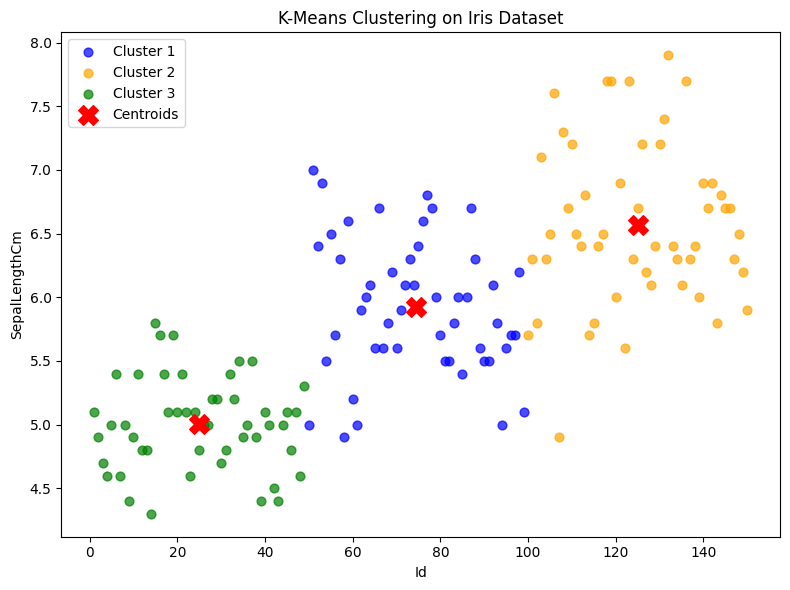

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
colors = ["blue", "orange", "green"]

for i in range(k):
    cluster_points = [X[j] for j, label in enumerate(labels) if label == i]
    if cluster_points:
        xs = [p[0] for p in cluster_points]
        ys = [p[1] for p in cluster_points]
        plt.scatter(xs, ys, s=40, color=colors[i], label=f"Cluster {i+1}", alpha=0.7)

cent_x = [c[0] for c in centroids]
cent_y = [c[1] for c in centroids]
plt.scatter(cent_x, cent_y, s=200, color="red", marker="X", label="Centroids")

plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])
plt.title("K-Means Clustering on Iris Dataset")
plt.legend()
plt.tight_layout()
plt.show()